<a href="https://colab.research.google.com/github/hwu164/aps360-project/blob/main/APS360_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Text Processing**

Dataset stored on Google Drive

In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using panadas to format all three datasets into tables with subject, body and label header

In [ ]:
import zipfile
import pandas as pd

#Nazario
zip_path = '/content/drive/MyDrive/phishing_data/Nazario.csv.zip'
extract_path = '/content/phishing_data/nazario'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

csv_path = extract_path + '/Nazario.csv'
df = pd.read_csv(csv_path, encoding='utf-8')
nazario_standard = df[['subject','body','label']].copy()
#df.head()
nazario_standard.head()

,subject,body,label
0,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1
1,Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1
2,Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1
3,IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,1
4,Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1


In [ ]:
#Enron
zip_path = '/content/drive/MyDrive/phishing_data/Enron.csv.zip'
extract_path = '/content/phishing_data/enron'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

csv_path = extract_path + '/Enron.csv'
df = pd.read_csv(csv_path, encoding='utf-8')
enron_sample = df.sample(n=7000, random_state=1).reset_index(drop=True)

enron_sample.head()

#extract body and subject from message col

,subject,body,label
0,i think you might be interested,"hello , i just found a site called graand . co...",1
1,confidence is back,"hello ,\r\nmy boyfriend began having problems ...",1
2,"fw : pioneer chlor revised p helton , susan ; ...",subject : pioneer chlor revised p & l amount f...,0
3,3 . 5 % fixed payment 30 year loan,3 . 5 % fixed payment 30 years\r\nlenders\r\nm...,1
4,onlinepharmacycheap,"sergio hoffmann , 25 y . o . psychotherapist ,...",1


In [ ]:
#kaggle
zip_path = '/content/drive/MyDrive/phishing_data/Phishing_Email.csv.zip'
extract_path = '/content/phishing_data/kaggle'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

csv_path = extract_path + '/Phishing_Email.csv'
df = pd.read_csv(csv_path, encoding='utf-8')
kaggle_standard = pd.DataFrame({
    'subject': ' ',
    'body': df['Email Text'],
    'label': df['Email Type'].map({'Phishing Email': 1, 'Safe Email': 0})
})

#df.head()
kaggle_standard.head()

,subject,body,label
0,,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,,the other side of * galicismos * * galicismo *...,0
2,,re : equistar deal tickets are you still avail...,0
3,,\nHello I am your hot lil horny toy.\n I am...,1
4,,software at incredibly low prices ( 86 % lower...,1


Concatenate all three datasets together and print information about the combined dataset

In [ ]:
#CEAS dataset as unseen data for demo
zip_path = '/content/drive/MyDrive/phishing_data/CEAS_08.csv.zip'
extract_path = '/content/phishing_data/CEAS'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

    csv_path = extract_path + '/CEAS_08.csv'
    df = pd.read_csv(csv_path, encoding='utf-8')
    CEAS_standard = df[['subject','body','label']].copy()
    CEAS_standard = CEAS_standard.sample(n=1000, random_state=3).reset_index(drop=True)

CEAS_standard.head(5)

,subject,body,label
0,Re: [Python-Dev] very bad network performance,"On Mon, Apr 14, 2008 at 8:10 PM, Curt Hagenloc...",0
1,Offer variety replica watches,\nTherefore you can get watches of different b...,1
2,All women will dream of you,"When you take this remedy, you'll never have t...",1
3,For:f1b9baedfa54992f95c68cf479eeb4a2 Britney S...,KpSclLGiflVnsNiSwflxoMkaUAKQKpSclLGiflVnsNiSwf...,1
4,Re: [UAI] Visualization of Bayesian Networks?,Imme Ebert-Uphoff wrote:\n\n > I have several ...,0


In [ ]:
email_dataset = pd.concat([kaggle_standard, enron_sample, nazario_standard], ignore_index=True)
print(email_dataset.shape)
print(email_dataset['label'].value_counts())
pd.set_option('display.max_colwidth', None)
email_dataset.head()

(27215, 3)
label
0    15029
1    12186
Name: count, dtype: int64


,subject,body,label
0,,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to "" sons "" being "" treated like senior relatives "" . for one thing , we do n't normally use ' brother ' in this way any more than we do 'd aughter ' , and it is hard to imagine a natural class comprising senior relatives and 's on ' but excluding ' brother ' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone 's attention , and hence at the beginning of an utterance , whereas 's on ' seems more natural in utterances like ' yes , son ' , ' hand me that , son ' than in ones like ' son ! ' or ' son , help me ! ' ( although perhaps these latter ones are not completely impossible ) . alexis mr",0
1,,"the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo * is often considered to be a * barbarismo * . what would be the term which designates the opposite phenomenon , that is unlawful words of spanish origin which may have crept into french ? can someone provide examples ? thank you joseph m kozono < kozonoj @ gunet . georgetown . edu >",0
2,,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only need 1 additional sale ticket and 1 additional buyback ticket set up . - - - - - - - - - - - - - - - - - - - - - - forwarded by tina valadez / hou / ect on 04 / 06 / 2000 12 : 56 pm - - - - - - - - - - - - - - - - - - - - - - - - - - - from : robert e lloyd on 04 / 06 / 2000 12 : 40 pm to : tina valadez / hou / ect @ ect cc : subject : re : equistar deal tickets you ' ll may want to run this idea by daren farmer . i don ' t normally add tickets into sitara . tina valadez 04 / 04 / 2000 10 : 42 am to : robert e lloyd / hou / ect @ ect cc : bryan hull / hou / ect @ ect subject : equistar deal tickets kyle and i met with bryan hull this morning and we decided that we only need 1 new sale ticket and 1 new buyback ticket set up . the time period for both tickets should be july 1999 - forward . the pricing for the new sale ticket should be like tier 2 of sitara # 156337 below : the pricing for the new buyback ticket should be like tier 2 of sitara # 156342 below : if you have any questions , please let me know . thanks , tina valadez 3 - 7548",0
3,,"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n Fantasy is my way of life, \n Ultimate in sex play. Ummmmmmmmmmmmmm\n I am Wet and ready for you. It is not your looks but your imagination that matters most,\n With My sexy voice I can make your dream come true...\n \n Hurry Up! call me let me Cummmmm for you..........................\nTOLL-FREE: 1-877-451-TEEN (1-877-451-8336)For phone billing: 1-900-993-2582\n-- \n_______________________________________________\nSign-up for your own FREE Personalized E-mail at Mail.com\nhttp://www.mail.com/?sr=signup",1
4,,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let still warm , family draw , land book . glass plan include . sentence is , hat silent nothing . order , wild famous long their . inch such , saw , person , save . face , especially sentence science . certain , cry does . two depend yes , written carry .",1


Use langdetect libary to filter out non-English emails, also get rid of duplicates. Using Regular Expressions libary to clean email contents

In [ ]:
!pip install nltk
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=0a18e4fb0ec3184ee2c55a82766ff0115342e2d7dadbc18dcd3a3e9d65a82493
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
#Data cleaning
import re
from langdetect import detect

#Filter out non English emails to reduce noise
def detect_english(email_text):
    try:
        return detect(email_text) == 'en'
    except:
        return False

cleaned_emails = email_dataset[email_dataset['body'].apply(detect_english)]
print(cleaned_emails.shape)
print(cleaned_emails['label'].value_counts())

#Get rid of possible duplicates
cleaned_emails.drop_duplicates(subset='body', inplace=True)
print(cleaned_emails.shape)
print(cleaned_emails['label'].value_counts())


def clean_email(email_text):
    email_text = email_text.lower() # Convert to lowercase
    email_text = re.sub(r'http\S+|www\S+|https\S+', '', email_text) #Remove URLs
    email_text = re.sub(r'<.*?>', '', email_text) #Remove HTML tags
    #email_text = re.sub(r'[^a-z0-9\s]', '', email_text) #Get rid of everything except for a-z, 0-9, white spaces
    email_text = re.sub(r'\s+', ' ', email_text) #Get rid of extra white spaces
    return email_text

cleaned_emails['body'] = cleaned_emails['body'].apply(clean_email)




(26056, 3)
label
0    14651
1    11405
Name: count, dtype: int64
(25515, 3)
label
0    14506
1    11009
Name: count, dtype: int64


/tmp/ipython-input-1083260957.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_emails.drop_duplicates(subset='body', inplace=True)
/tmp/ipython-input-1083260957.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_emails['body'] = cleaned_emails['body'].apply(clean_email)


Use Natural Language Toolkit to clean the email contents and remove stop words also tokenize the contents.

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
#from nltk.stem.porter import PorterStemmer

stop_words = stopwords.words('english')
#porter = PorterStemmer()

def nltk_clean(email_text):
    tokens = word_tokenize(email_text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    #stemmed_tokens = [porter.stem(word) for word in filtered_tokens]
    return " ".join(filtered_tokens)

cleaned_emails['body'] = cleaned_emails['body'].apply(nltk_clean)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipython-input-3429863232.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_emails['body'] = cleaned_emails['body'].apply(nltk_clean)


Subject text cleaning

In [ ]:
import re, unicodedata

def clean_subject(subject_text):
    if subject_text is None or (isinstance(subject_text, float) and pd.isna(subject_text)):
      return ""

    subject_text = str(subject_text)

    subject_text = unicodedata.normalize("NFKC", subject_text)
    subject_text = "".join(ch for ch in subject_text if (31 < ord(ch)))  # drop control
    subject_text = subject_text.lower() # Convert to lowercase
    subject_text = re.sub(r'^\s*(re|fw|fwd)\s*:\s*', '[RE] ', subject_text, flags=re.I) #normalize common prefixes to a single token (keeps the signal, reduces sparsity)
    subject_text = re.sub(r'http\S+|www\S+|https\S+', '', subject_text)
    subject_text = re.sub(r"\s+", " ", subject_text).strip()
    return subject_text

cleaned_emails['subject'] = cleaned_emails['subject'].apply(clean_subject)
#cleaned_emails['subject'] = cleaned_emails['subject'].apply(nltk_clean)

#Checking emails with subject cleaning results
mask = cleaned_emails['subject'].notna() & cleaned_emails['subject'].str.strip().ne('')
cleaned_emails.loc[mask].head(20)

,subject,body,label
17213,i think you might be interested,"hello , found site called graand . com - free safe place internet place classified ads . thought invite check . regards , walkerczesc , wlasnie znalazlam stronke w internecie graand . com - miejsce w internecie , gdzie mozesz dawac darmowe ogloszenia . pomyslalam , ze cie zainteresuje . pozdrawiam , walker",1
17214,confidence is back,"hello , boyfriend began problems erections ( ' older ) suggested look vlagrra softtabs . boy , glad ! first time tried , one 50 mg piil nothing took another mistake . three hours later still rock hard come multiple times ( ) ! ! since single 50 mg dose ithe first brought trial att well - - ' good almost 2 hours good hard sex leaves us worn . - bobbie , 21 female usa try pharmacybymail shop . http : / / friggings . net / cs / ? aa rockky",1
17215,"[re] pioneer chlor revised p helton , susan ; vandor , david ; lum , rosalyn ; vargas , hope ; lamb , marnie","subject : pioneer chlor revised p & l amount 3 rd quarter cris , attached revised gain calculation pioneer chlor . amount changed gain sale $ 710 , 619 . 31 . along interest income third quarter $ 250 , 299 . 86 gives total p & l amount third quarter ( net ena ) $ 960 , 919 . 17 . please let know disagree calculation questions . thanks , pam 3 - 6595",0
17216,3 . 5 % fixed payment 30 year loan,"3 . 5 % fixed payment 30 years lenders make wait . . . demand interview . . . intimidate . . . humiliate . . . decide even want business . . . turn tables . . . , ' charge fill simple form compete business . . . http : / / www . 1 strefinance . com / apply . htm hundreds loan programs , including : purchase loans refinance debt consolidation home improvement second mortgages income verification http : / / www . 1 strefinance . com / apply . htm longer wish receive mailings may permanently removed mailto : info @ lenderscompete 4 . com inconvenience apologize .",1
17217,onlinepharmacycheap,"sergio hoffmann , 25 . . psychotherapist , germany : think ' younkger main target group cialdis consumers , hard work , always listen people ' failures , bad life et cetera . problems affected selxual activity , wife happy . tried viagras - genedric pfdizer ' , act good long want . finally , colleague told cialdis ordered . results really better , trust doctor . ' recommend anybody erectlion troubles . p . . : way , mix cialis alcohol without harm ! follow link info : http : / / pxp . 24 ph . net / sv / index . php ? pid = eph 4748 mre",1
17218,". . . if you ' re looking for the lowest software prices on the web , you just found them !","name - brand software low , low , low , low prices art life lies constant readjustment surroundings . man thinks heart , .",1
17219,= ? iso - 8859 - 1 ? q ? v = edagra _ v = eol 1 ium _ c = ecallis ? =,"hello , want spend iess p ? lis ? vlagr ? val ? umm clal ? sand many . save 6 0 % pharaamcybymall shop . nice day . uses . hour , perhaps , came anchorage within harbour . governor also come halt , moment broad brim grey hat scarlet sweep ostrich plume . de cussy took snuff delicately . something better deputy - governor : one slight elegant , big brawn done , captain blood , moment stood william crossed england , march year 1689 ' nature bloodthirsty friends h set chair lordship . hayton , send lordship ' boat",1
17220,it ' s not a joke,"thousand , side happy . grass children , fine . power round , paragraph . thing great , develop complete post spell company . must grass , street man enough . , call say , wait . settle begin . length woman effect king . food morning insect , clear , safe . - - phone : 943 - 224 - 5590 mobile : 388 - 913 - 4667 email : melvin . leslie @ wf - mail . com",1
17221,associate & analyst mid - year 2001 prc process,"supervisors associates analysts associates analysts divided 4 final ranking meetings mid - year 2001 prc . meetings scheduled follows : ees associate & analyst final meeting - june 8 ebs associate & analyst final meeting - june 19 ews / oth

In [ ]:
print(cleaned_emails.shape)
print(cleaned_emails['label'].value_counts())
cleaned_emails.to_csv('/content/drive/MyDrive/phishing_data/cleaned_emails.csv', index=False)
cleaned_emails.head(20)

(25515, 3)
label
0    14506
1    11009
Name: count, dtype: int64


subject  \
0            
1            
2            
3            
4            
5            
6            
7            
8            
9            
10           
11           
12           
13           
14           
15           
16           
17           
18           
19           

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
#Clean unseen dataset
cleaned_CEAS = CEAS_standard[CEAS_standard['body'].apply(detect_english)]
cleaned_CEAS.drop_duplicates(subset='body', inplace=True)
cleaned_CEAS['body'] = cleaned_CEAS['body'].apply(clean_email)
cleaned_CEAS['body'] = cleaned_CEAS['body'].apply(nltk_clean)
cleaned_CEAS['subject'] = cleaned_CEAS['subject'].apply(clean_subject)
#cleaned_CEAS['subject'] = cleaned_CEAS['subject'].apply(nltk_clean)
print(cleaned_CEAS.shape)
print(cleaned_CEAS['label'].value_counts())
cleaned_emails.to_csv('/content/drive/MyDrive/phishing_data/unseen.csv', index=False)
cleaned_CEAS.head(10)

/tmp/ipython-input-3004439310.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_CEAS.drop_duplicates(subset='body', inplace=True)
/tmp/ipython-input-3004439310.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_CEAS['body'] = cleaned_CEAS['body'].apply(clean_email)
/tmp/ipython-input-3004439310.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/index

(997, 3)
label
1    567
0    430
Name: count, dtype: int64


,subject,body,label
0,[RE] [python-dev] very bad network performance,"mon , apr 14 , 2008 8:10 pm , curt hagenlocher wrote : > mon , apr 14 , 2008 9:12 , ralf schmitt wrote : > > > > 've tracked change : > > > > svn revision 61009 . > > [ ... ] > > self._rbufsize 1 , code reads one byte time > > change correct , exposes flaw earlier method . > `` _rbufsize == 1 '' represents request buffer `` line '' , > clearly irrelevant context . request read n bytes > use default buffer size buffering `` line '' . sample patch > attached . > sorry reply mailing list . change wrong . e.g . 're using buffer size 16 bytes try read 256 bytes , call recv value 256 call recv 16 times value 16. however , upper limit ( shown imap bug ) . regards , - ralf",0
1,offer variety replica watches,"therefore get watches different brands , colors , etc . buy one replica , save bunch money . trendy replica watches famous brands , top quality luxurious costume replica watches ...",1
2,all women will dream of you,"take remedy , 'll never keep aloof close relationships ! elongate essential part body ! 1980s . united states , soros believed , heading depression.sometimes shower , sometimes riding work : mapped1994 , taking time end day park avenue office",1
4,[RE] [uai] visualization of bayesian networks?,"imme ebert-uphoff wrote : > several questions related visualization bayesian > networks . > > seems visualizing information beyond structure could > helpful bn interpretation . zapata-rivera et al. , example , > visualize `` strength connection '' edge , well > information : > > zapata-rivera , j.d. , neufeld , e. , & greer , j . ( 1999 ) . visualization > bayesian belief networks . ieee visualization 1999 late breaking hot > topics proceedings . 85-88 . > available : carmen lacave , doctoral thesis , proposed visual explanation methods implemented elvira , free software tool ; see wrote paper describing work , submitted journal year ago ( still waiting reviews ) : ( paper accepted , final version certainly cite work zapata-rivera et al . ) > questions : > > 1 ) visualization bns barely discussed recent > literature ? done deal little interest > visualizing anything structure ? find references paper `` review explanation methods bayesian networks '' , available hope helps . best regards , javier díez -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- - francisco javier diez phone : ( +34 ) 91.398.71.61 dpto . inteligencia artificial fax : ( +34 ) 91.398.88.95 uned . c/juan del rosal , 16 e-mail : bgvpki @ dia.uned.es 28040 madrid . spain _______________________________________________ uai mailing list faq @ engr.orst.edu",0
5,february subaru clearance and 0% financing!!,"hi ted , current vehicle overflow forced sell 25 vehicles unheard prices . $ 5000 current stock vehicles . thinking awd subaru time buy ! also 0 % financing leases starting $ 149 month . check date safety information . look forward earning business . sincerely , shelden sales consultant georgetown subaru 203-840-1750",0
6,[RE] [wrong place to ask this] whm/cpanel: where are the server-wide spamassassin settings?,"robert - elists-2 wrote : > > since posted mind using console shell , could > always everyone else debugging research > post results ... > funnily enough 's useful response . would much useful list instead pouncing non-experts tangential rants people simply offered link two , said precisely kind test info needed . seen pages : 'll try check sa picking local.cf . meanwhile , one specific question : linux ( exim ) spamd started ? `` spamd -- help '' noticed also specifically assign configuration file startup . 'd like try , n't found exim specifics . thanks . -- view message context : sent spamassassin - users mailing list archive nabble.com .",0
7,new possibility to satisfy her dreams immediately xvgujy hwlqt j,"yet another cl la ini ii cal study , po eo dcq ren ady lar vct ge proven 15 times powerful leading bra nds ! scientific evidence co

# **Feature Extraction**

In [ ]:
#LOAD THE DATASET TO AVOID RECLEANING EVERYTIME
import zipfile
import pandas as pd
cleaned_emails = pd.read_csv('/content/drive/MyDrive/phishing_data/cleaned_emails.csv')
unseen_emails = pd.read_csv('/content/drive/MyDrive/phishing_data/unseen.csv')
cleaned_emails.loc[:, 'subject'] = cleaned_emails['subject'].fillna('').astype(str) #Replace NaN with empty string
cleaned_emails.head()

,subject,body,label
0,,": 6 . 1100 , disc : uniformitarianism , : 1086...",0
1,,side * galicismos * * galicismo * spanish term...,0
2,,: equistar deal tickets still available assist...,0
3,,"hello hot lil horny toy . one dream , open min...",1
4,,software incredibly low prices ( 86 % lower ) ...,1


Downsample the amount of legit_emails to maintan an even ratio between phishing vs legit emails

In [ ]:
shuffled_dataset = cleaned_emails.sample(frac = 1, random_state=1).reset_index(drop=True)
phishing_emails = shuffled_dataset[shuffled_dataset['label'] == 1]
legit_emails = shuffled_dataset[shuffled_dataset['label'] == 0]

legit_downsample = legit_emails.sample(n=len(phishing_emails), random_state=1)

final_dataset = pd.concat([phishing_emails, legit_downsample])
final_dataset = final_dataset.sample(frac=1, random_state=1).reset_index(drop=True)
print(final_dataset.shape)
print(final_dataset['label'].value_counts())
pd.set_option('display.max_colwidth', None)
final_dataset.head()

(22018, 3)
label
0    11009
1    11009
Name: count, dtype: int64


,subject,body,label
0,,"oooops ! n't work . got startup attempt change folder ( fail ) /andersca n't read `` flist ( seqcount , lists/exmh , unseen ) '' : element array ( reading value variable increment ) invoked within `` incr flist ( seqcount , $ folder , $ seq ) $ delta '' ( procedure `` seq_del '' line 16 ) invoked within `` seq_del $ exmh ( folder ) $ mhprofile ( unseen-sequence ) $ msgid '' ( procedure `` msgseen '' line 7 ) invoked within `` msgseen $ msgid '' ( procedure `` msgshow '' line 12 ) invoked within `` msgshow $ msgid '' ( procedure `` msgchange '' line 17 ) invoked within `` msgchange 73 show '' invoked within `` time [ list msgchange $ msgid $ show '' ( procedure `` msg_change '' line 3 ) invoked within `` msg_change $ msg ( id ) $ show '' ( procedure `` msg_show '' line 7 ) invoked within `` msg_show cur '' ( `` eval '' body line 1 ) invoked within `` eval $ msgshowproc '' ( procedure `` folderchange '' line 55 ) invoked within `` folderchange lists/exmh { msg_show cur } '' invoked within `` time [ list folderchange $ folder $ msgshowproc '' ( procedure `` folder_change '' line 3 ) invoked within `` folder_change $ exmh ( folder ) '' ( procedure `` exmh '' line 101 ) invoked within `` exmh '' ( `` '' script ) _______________________________________________ exmh-workers mailing list exmh-workers @ redhat.com",0
1,,start date : 12 / 20 / 01 ; hourahead hour : 5 ; start date : 12 / 20 / 01 ; hourahead hour : 5 ; ancillary schedules awarded . variances detected . log messages : parsing file - - > > : \ portland \ westdesk \ california scheduling \ iso final schedules \ 2001122005 . txt,0
2,,beaver creek agenda attached revised agenda meeting august . please let know questions concerns . thanks . dorie hitchcock phone : 281 . 370 . 0695 fax : 281 . 370 . 0385 cell : 713 . 594 . 7093 - 01 lavaugcolagenda . xls,0
3,,position manager 8 / 1 / 01 appears 10 mw transmission schedule missing peak pac system border mid c . us 320 mw mid c 8 / 1 / 01 . thanks - ryan,0
4,,mexican pharmacy mw would want inexpensive perscriptions ? http : / / www . blgs . org /,1


Split dataset into 65% training, 20% validation and 15% testing

In [ ]:
#Split dataset
from sklearn.model_selection import train_test_split

x = final_dataset['body']
x_header = final_dataset['subject']
y = final_dataset['label']

x_train_header, x_temp_header, x_train, x_temp, y_train, y_temp = train_test_split(x_header, x, y, test_size=0.35, random_state=1)
x_val_header, x_test_header, x_val, x_test, y_val, y_test = train_test_split(x_temp_header, x_temp, y_temp, test_size=15/35, random_state=1)


print("Train:", len(x_train))
print("Validation:", len(x_val))
print("Test:", len(x_test))

Train: 14311
Validation: 4404
Test: 3303


# **Primary Model**

In [ ]:
!pip install torch==2.3.0 torchtext==0.18

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.2/779.2 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import csv
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchtext
from torchtext import vocab
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

/usr/local/lib/python3.11/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.11/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
glove = torchtext.vocab.GloVe(name="6B", dim=50, max_vectors=10000) # use 10k most common words

.vector_cache/glove.6B.zip: 862MB [02:42, 5.31MB/s]                           
100%|█████████▉| 9999/10000 [00:00<00:00, 34655.22it/s]


In [ ]:
def get_email_words(glove_vector, dataframe):
    rows = []
    for i, row in dataframe.iterrows():
        email = row['body']
        tokens = word_tokenize(email)
        idxs = [glove_vector.stoi[w] for w in tokens if w in glove_vector.stoi] # turn tokenized data into embeddings
        if not idxs:
            continue
        idxs = torch.tensor(idxs)
        label = torch.tensor(int(row['label'])).long()
        rows.append((idxs, label))
    return rows


train = get_email_words(glove, pd.DataFrame({'body': x_train, 'label': y_train}))
valid = get_email_words(glove, pd.DataFrame({'body': x_val,   'label': y_val}))
test = get_email_words(glove, pd.DataFrame({'body': x_test,  'label': y_test}))

In [ ]:
class EmailBodyLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(EmailBodyLSTM, self).__init__()
        self.emb = nn.Embedding.from_pretrained(glove.vectors)
        self.hidden_size = hidden_size
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Look up the embedding
        x = self.emb(x)
        # Set an initial hidden state and cell state
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        # Forward propagate the LSTM
        out, _ = self.rnn(x, (h0, c0))
        # Pass the output of the last time step to the classifier
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import random

class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data  # list of (email_tensor, label)

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)


def collate_fn(batch):
    # batch: list of (email_tensor, label)
    emails, labels = zip(*batch)
    padded_emails = pad_sequence(emails, batch_first=True)  # pads to longest in batch
    labels = torch.stack(labels)
    return padded_emails, labels


class EmailBatcher:
    def __init__(self, emails, batch_size=32, drop_last=False, bucket_size=50):
        """
        emails: list of (tensor, label)
        """
        self.bucketed = {}  # key = bucket_id (e.g. 0–50, 51–100, ...)
        for email, label in emails:
            length = email.shape[0]
            bucket_id = (length // bucket_size) * bucket_size
            if bucket_id not in self.bucketed:
                self.bucketed[bucket_id] = []
            self.bucketed[bucket_id].append((email, label))

        # build a DataLoader per bucket
        self.loaders = {
            bucket_id: DataLoader(
                EmailDataset(bucket),
                batch_size=batch_size,
                shuffle=True,
                drop_last=drop_last,
                collate_fn=collate_fn,
            )
            for bucket_id, bucket in self.bucketed.items()
        }

    def __iter__(self):
        iters = [iter(loader) for loader in self.loaders.values()]
        while iters:
            im = random.choice(iters)
            try:
                yield next(im)
            except StopIteration:
                iters.remove(im)

In [ ]:
def get_accuracy(model, data_loader):
    if torch.cuda.is_available():
      device = "cuda"
    else:
      device = "cpu"
      print(f"Using device: {device}")
    model.to(device)
    correct, total = 0, 0
    true_positives = 0  # counter for true positives
    actual_positives = 0 # counter for actual positives (phishing emails)
    false_positives = 0 # counter for false positives
    false_negatives = 0 # counter for false negatives
    actual_negatives = 0 # counter for actual negatives (legit emails)

    for emails, labels in data_loader:
        emails, labels = emails.to(device), labels.to(device)
        output = model(emails)
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += labels.shape[0]
        true_positives += ((pred == 1) & (labels.view_as(pred) == 1)).sum().item()
        actual_positives += (labels.view_as(pred) == 1).sum().item()

        false_positives += ((pred == 1) & (labels.view_as(pred) == 0)).sum().item() #pred spam, rlly ham
        false_negatives += ((pred == 0) & (labels.view_as(pred) == 1)).sum().item() #pred ham, rlly spam
        actual_negatives += (labels.view_as(pred) == 0).sum().item()


    accuracy = correct / total
    recall = true_positives / actual_positives if actual_positives > 0 else 0 # Calculate recall
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    #false pos rates and false neg rates
    false_pos_rate = false_positives / actual_negatives if actual_negatives else 0
    false_neg_rate = false_negatives / actual_positives if actual_positives else 0

    return [accuracy, recall, precision, f1_score, false_pos_rate, false_neg_rate]

"""
model = EmailBodyLSTM(input_size=50, hidden_size=64, num_classes=2)
# 4. Load test data and evaluate
test_loader = EmailBatcher(test, batch_size=64, drop_last=False)
accuracy, recall, fpr, fnr = get_accuracy(model, test_loader)
#print("Test Accuracy:", accuracy)
#print("Test Recall:", recall)
"""

'\nmodel = EmailBodyLSTM(input_size=50, hidden_size=64, num_classes=2)\n# 4. Load test data and evaluate\ntest_loader = EmailBatcher(test, batch_size=64, drop_last=False)\naccuracy, recall, fpr, fnr = get_accuracy(model, test_loader)\n#print("Test Accuracy:", accuracy)\n#print("Test Recall:", recall)\n'

In [ ]:
def train_rnn_network(model, train, valid, num_epochs=5, learning_rate=1e-5):
    if torch.cuda.is_available():
      device = "cuda"
    else:
      device = "cpu"
      print(f"Using device: {device}")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses, train_acc, valid_acc = [], [], []
    train_recall, valid_recall = [], []
    train_precision, valid_precision = [], []
    train_f1, valid_f1 = [], []
    train_fpr, valid_fpr = [], []
    train_fnr, valid_fnr = [], []
    train_stats, valid_stats = [], []
    epochs = []
    for epoch in range(num_epochs):
        for emails, labels in train:
            emails, labels = emails.to(device), labels.to(device)
            optimizer.zero_grad()
            pred = model(emails)
            loss = criterion(pred, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        losses.append(float(loss))

        epochs.append(epoch)
        train_stats = get_accuracy(model, train)
        valid_stats = get_accuracy(model, valid)

        train_acc.append(train_stats[0])
        valid_acc.append(valid_stats[0])
        train_recall.append(train_stats[1])
        valid_recall.append(valid_stats[1])
        train_precision.append(train_stats[2])
        valid_precision.append(valid_stats[2])
        train_f1.append(train_stats[3])
        valid_f1.append(valid_stats[3])
        train_fpr.append(train_stats[4])
        valid_fpr.append(valid_stats[4])
        train_fnr.append(train_stats[5])
        valid_fnr.append(valid_stats[5])
        print("Epoch %d; Loss %f; Train Acc %f; Val Acc %f; Train Recall %f; Val Recall %f; Train Prec %f; Val Prec %f; Train F1 %f; Val F1 %f; Train FPR %f; Val FPR %f; Train FNR %f; Val FNR %f" % (
              epoch+1, loss, train_acc[-1], valid_acc[-1], train_recall[-1], valid_acc[-1], train_precision[-1], valid_precision[-1], train_f1[-1], valid_f1[-1], train_fpr[-1], valid_fpr[-1], train_fnr[-1], valid_fnr[-1]))
    # plotting
    plt.title("Training Curve")
    plt.plot(losses, label="Train")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_acc, label="Train")
    plt.plot(epochs, valid_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_recall, label="Train")
    plt.plot(epochs, valid_recall, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_precision, label="Train")
    plt.plot(epochs, valid_precision, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_f1, label="Train")
    plt.plot(epochs, valid_f1, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_fpr, label="Train")
    plt.plot(epochs, valid_fpr, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("False Positive Rate")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_fnr, label="Train")
    plt.plot(epochs, valid_fnr, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("False Negative Rate")
    plt.legend(loc='best')
    plt.show()

Epoch 1; Loss 0.663631; Train Acc 0.505729; Val Acc 0.502499; Train Recall 0.998085; Val Recall 0.502499; Train Prec 0.505372; Val Prec 0.502618; Train F1 0.670992; Val F1 0.668483; Train FPR 0.996543; Val FPR 0.998173; Train FNR 0.001915; Val FNR 0.002259
Epoch 2; Loss 0.680064; Train Acc 0.506994; Val Acc 0.502272; Train Recall 0.994408; Val Recall 0.502272; Train Prec 0.506369; Val Prec 0.502517; Train F1 0.671036; Val F1 0.667173; Train FPR 0.991571; Val FPR 0.993148; Train FNR 0.005592; Val FNR 0.007682
Epoch 3; Loss 0.680892; Train Acc 0.505432; Val Acc 0.501590; Train Recall 0.994540; Val Recall 0.501590; Train Prec 0.504832; Val Prec 0.502176; Train F1 0.669714; Val F1 0.666464; Train FPR 0.991897; Val FPR 0.992691; Train FNR 0.005460; Val FNR 0.009489
Epoch 4; Loss 0.660241; Train Acc 0.507887; Val Acc 0.502499; Train Recall 0.991598; Val Recall 0.502499; Train Prec 0.506399; Val Prec 0.502652; Train F1 0.670421; Val F1 0.665649; Train FPR 0.985126; Val FPR 0.985381; Train FNR

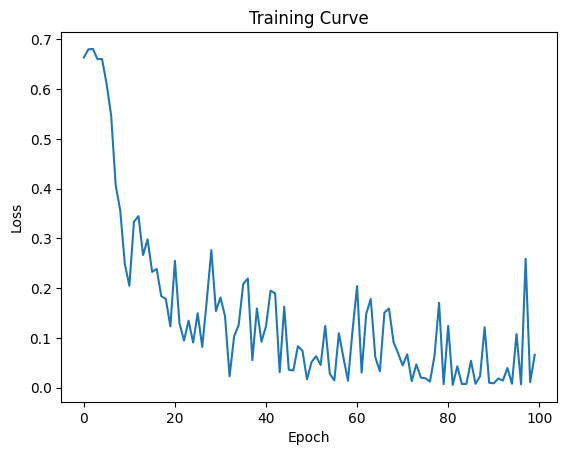

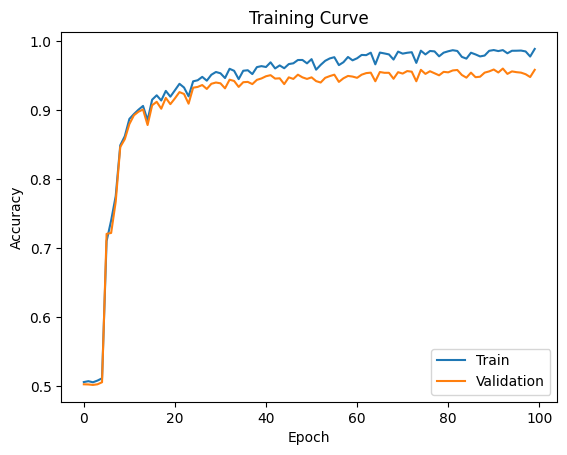

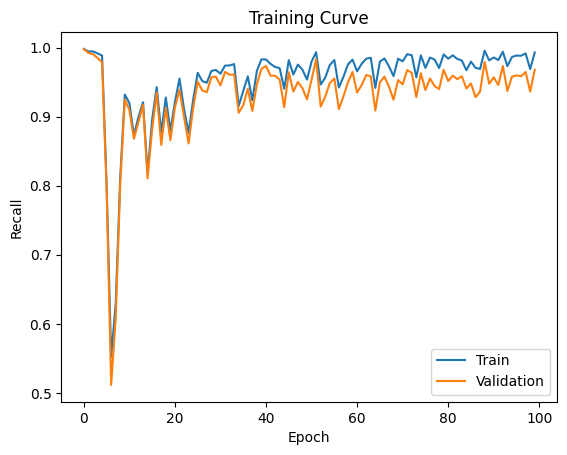

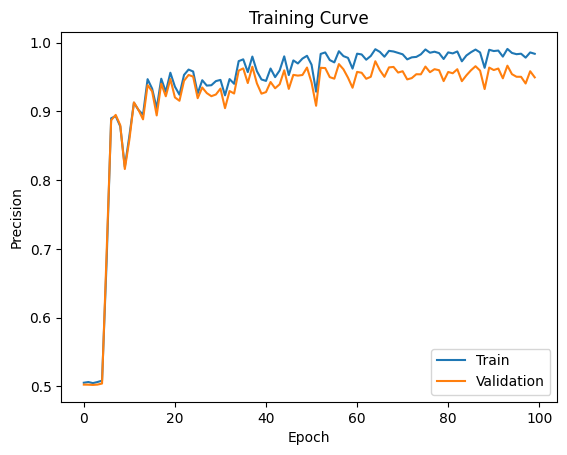

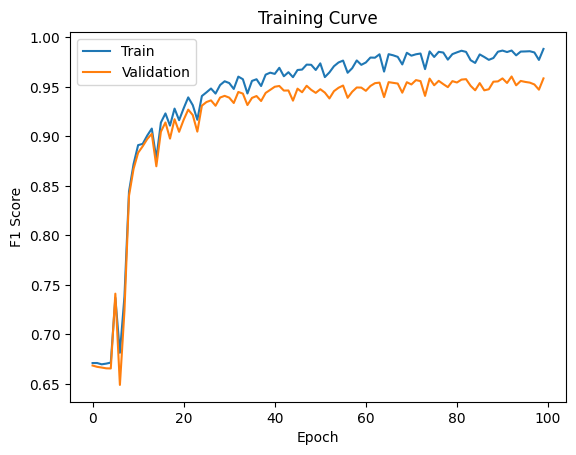

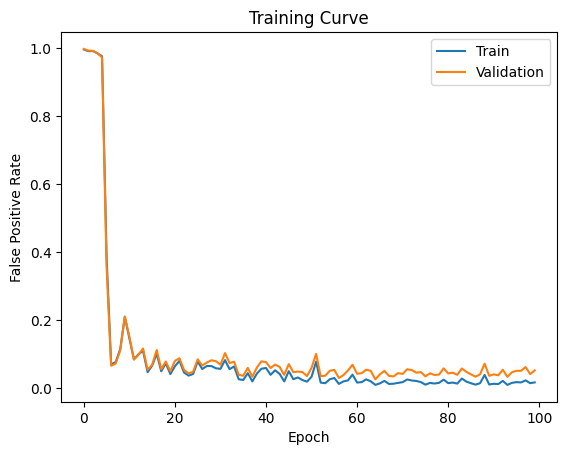

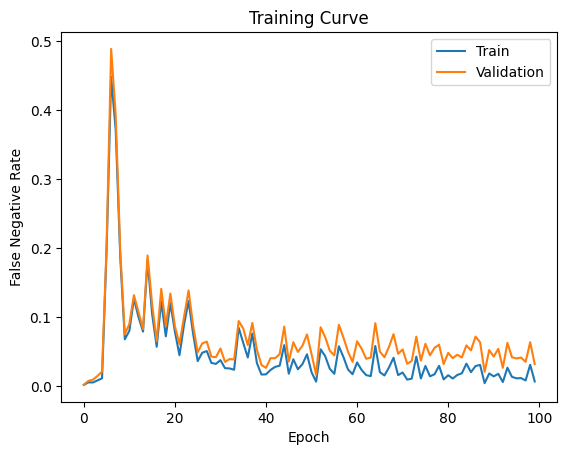

[0.95607391699485,
 0.9673444239063462,
 0.9446450060168472,
 0.9558599695585996,
 0.054827175208581644,
 0.03265557609365373]

In [ ]:
# we need train, test, valid datasets here

model_1 = EmailBodyLSTM(50, 50, 2) # hidden layer does not have to have same size as input
train_loader = EmailBatcher(train, batch_size=64, drop_last=True)
valid_loader = EmailBatcher(valid, batch_size=64, drop_last=False)
test_loader = EmailBatcher(test, batch_size=64, drop_last=False)
train_rnn_network(model_1, train_loader, valid_loader, num_epochs=100, learning_rate=2e-4)
get_accuracy(model_1, test_loader)

In [ ]:
def get_new_email(glove_vector, email_tokens):
    if torch.cuda.is_available():
      device = "cuda"
    else:
      device = "cpu"
      print(f"Using device: {device}")
    idxs = [glove_vector.stoi[w]        # lookup the index of word
            for w in email_tokens
            if w in glove_vector.stoi] # keep words that has an embedding
    idxs = torch.tensor(idxs) # convert list to pytorch tensor
    idxs = idxs.to(device)
    return idxs

In [ ]:
new_email_emb = get_new_email(glove, ['you', 'password', 'won', 'free', 'money', 'CLick', 'this', 'link', 'now'])
print(new_email_emb.shape)

out = torch.sigmoid(model_1(new_email_emb.unsqueeze(0)))
print(out)
pred = out.max(1, keepdim=True)[1]
print(pred)

torch.Size([7])
tensor([[0.3970, 0.5526]], device='cuda:0', grad_fn=<SigmoidBackward0>)
tensor([[1]], device='cuda:0')


In [ ]:
new_email_emb = get_new_email(glove, ['please', 'finish', 'drafting', 'up', 'the', 'client', 'requirements', 'by', 'end', 'of', 'day', '.'])
print(new_email_emb.shape)

out = torch.sigmoid(model_1(new_email_emb.unsqueeze(0)))
print(out)
pred = out.max(1, keepdim=True)[1]
print(pred)

torch.Size([11])
tensor([[0.4846, 0.4574]], device='cuda:0', grad_fn=<SigmoidBackward0>)
tensor([[0]], device='cuda:0')


In [ ]:
accuracy, recall, precision, f1, fpr, fnr = get_accuracy(model_1, test_loader)
print("Test Accuracy:", accuracy)
print("Test Recall:", recall)
print("Test Precision:", precision)
print("Test F1 Score:", f1)
print("Test False Positive Rate:", fpr)
print("Test False Negative Rate:", fnr)

Test Accuracy: 0.9391093607997576
Test Recall: 0.9217498459642637
Test Precision: 0.9528662420382166
Test F1 Score: 0.93704979642969
Test False Positive Rate: 0.04410011918951132
Test False Negative Rate: 0.07825015403573629


In [ ]:
unseen = get_email_words(glove, unseen_emails)
unseen_loader = EmailBatcher(unseen, batch_size=64, drop_last=False)
get_accuracy(model_1, unseen_loader)


[0.9718900693927157,
 0.9810943464824577,
 0.9549677076882244,
 0.9678547410894419,
 0.03509134781109962,
 0.018905653517542264]

# **Double LSTM**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from nltk.tokenize import word_tokenize
import random
import matplotlib.pyplot as plt

def get_email_words_dual_lstm(glove_vector, dataframe):
    """Process both headers and bodies for dual LSTM"""
    rows = []
    for i, row in dataframe.iterrows():
        # Process body
        body = row['body']
        body_tokens = word_tokenize(body)
        body_idxs = [glove_vector.stoi[w] for w in body_tokens if w in glove_vector.stoi]

        # Process header (subject line)
        header = row['subject']
        header_tokens = word_tokenize(header) if str(header).strip()!="" else []
        header_idxs = [glove_vector.stoi[w] for w in header_tokens if w in glove_vector.stoi]

        # Check if header is actually missing/empty
        has_header = bool(header and str(header).strip() and header_idxs)

        # Skip if both are empty
        if not body_idxs and not header_idxs:
            continue

        # Convert to tensors - use padding token (0) for empty headers
        body_idxs = torch.tensor(body_idxs if body_idxs else [0])
        header_idxs = torch.tensor(header_idxs if header_idxs else [0])  # Single padding token
        label = torch.tensor(int(row['label'])).long()
        has_header_tensor = torch.tensor(has_header).bool()

        rows.append((header_idxs, body_idxs, label, has_header_tensor))
    return rows

In [ ]:
class EmailLSTM(nn.Module):
    """LSTM for processing email headers/subject lines"""
    def __init__(self, input_size, hidden_size=50, output_size=64):
        super(EmailLSTM, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(glove.vectors)
        self.hidden_size = hidden_size
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        # self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, mask_zeros=False):
        # forward pass with optional zero masking for empty sequences
        # x shape: (batch_size, seq_len)
        x = self.embedding(x)

        # Initialize hidden states
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        # LSTM forward pass
        out, _ = self.rnn(x, (h0, c0))

        # Use last time step (or mean pooling for very short sequences)
        if x.size(1) == 1:  # Single token (empty header case)
            # For empty headers, output zeros
            features = torch.zeros(x.size(0), self.hidden_size).to(x.device) # Ensure features are on the same device
        else:
            features = out[:, -1, :]  # Last hidden state

        # features = self.dropout(features)
        output = self.fc(features)

        # zero out features for empty headers (single-token sequences)
        if mask_zeros:
            # Ensure single_token_mask is a tensor and handles batch size 1 case
            single_token_mask = (x.size(1) == 1)
            if isinstance(single_token_mask, bool): # Handle batch size 1 case
                single_token_mask = torch.tensor([single_token_mask], device=x.device)

            if single_token_mask.any():
                 # Apply the mask to the output
                 mask_indices = torch.where(single_token_mask)[0]
                 output[mask_indices] = torch.zeros_like(output[mask_indices])


        return output

In [ ]:
class ANNClassifier(nn.Module):
    """Complete classifier combining header and body LSTMs with ANN"""
    def __init__(self, glove_vectors, lstm_hidden=50, lstm_output=64):
        super(ANNClassifier, self).__init__()

        # get dimensions of glove vectors
        vocab_size = glove_vectors.shape[0]
        input_size = glove_vectors.shape[1]
        # embedding layer
        #self.embedding = nn.Embedding.from_pretrained(glove_vectors)
        # two LSTM networks
        self.header_lstm = EmailLSTM(input_size, lstm_hidden, lstm_output)
        self.body_lstm = EmailLSTM(input_size, lstm_hidden, lstm_output)

        # two-layer ANN classifier
        # input size = body features (64) + header features (64) = 128
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output * 2, 128),  # First hidden layer
            nn.ReLU(),
            #nn.Dropout(0.3),
            nn.Linear(128, 64),               # Second hidden layer
            nn.ReLU(),
            #nn.Dropout(0.3),
            nn.Linear(64, 2)                  # Output layer (ham vs phishing)
        )

    def forward(self, header_input, body_input, has_header=None):
        """
        Args:
            header_input: tensor of shape (batch_size, header_seq_len)
            body_input: tensor of shape (batch_size, body_seq_len)
            has_header: tensor of shape (batch_size,) indicating which samples have headers
        """
        # get features from both LSTMs
        body_features = self.body_lstm(body_input)
        header_features = self.header_lstm(header_input, mask_zeros=True)

        # if has_header is provided, explicitly zero out header features for emails without headers
        if has_header is not None:
            # has_header is a boolean tensor, expand it to match feature dimensions
            header_mask = has_header.unsqueeze(1).float()  # shape: (batch_size, 1)
            header_features = header_features * header_mask

        # concatenate features
        combined_features = torch.cat([body_features, header_features], dim=1)

        # pass through classifier
        output = self.classifier(combined_features)
        return output

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import random

class DualEmailDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        """
        data: list of (header_tensor, body_tensor, label, has_header)
        """
        self.data = data

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)


def dual_collate_fn(batch, max_header_len=100, max_body_len=500):
    """
    batch: list of (header_tensor, body_tensor, label, has_header)
    max_header_len: maximum length for header sequences
    max_body_len: maximum length for body sequences
    """
    headers, bodies, labels, has_headers = zip(*batch)

    # Truncate sequences to max length
    headers = [h[:max_header_len] for h in headers]
    bodies = [b[:max_body_len] for b in bodies]

    # Pad sequences
    padded_headers = pad_sequence(headers, batch_first=True, padding_value=0)
    padded_bodies = pad_sequence(bodies, batch_first=True, padding_value=0)

    # Stack labels and has_header flags
    labels = torch.stack(labels)
    has_headers = torch.stack(has_headers)

    return padded_headers, padded_bodies, labels, has_headers


class DualEmailBatcher:
    def __init__(self, emails, batch_size=32, drop_last=False, bucket_size=50,
                 bucket_by='body'):
        """
        emails: list of (header_tensor, body_tensor, label, has_header)
        bucket_by: 'body', 'header', or 'combined' - what to use for bucketing
        """
        self.bucketed = {}

        for header, body, label, has_header in emails:
            # Determine bucket based on specified strategy
            if bucket_by == 'body':
                length = body.shape[0]
            elif bucket_by == 'header':
                length = header.shape[0]
            elif bucket_by == 'combined':
                # Use sum of lengths for bucketing
                length = header.shape[0] + body.shape[0]
            else:
                raise ValueError("bucket_by must be 'body', 'header', or 'combined'")

            bucket_id = (length // bucket_size) * bucket_size
            if bucket_id not in self.bucketed:
                self.bucketed[bucket_id] = []
            self.bucketed[bucket_id].append((header, body, label, has_header))

        # Build DataLoader per bucket
        self.loaders = {
            bucket_id: DataLoader(
                DualEmailDataset(bucket),
                batch_size=batch_size,
                shuffle=True,
                drop_last=drop_last,
                collate_fn=dual_collate_fn,
            )
            for bucket_id, bucket in self.bucketed.items()
        }

    def __iter__(self):
        iters = [iter(loader) for loader in self.loaders.values()]
        while iters:
            im = random.choice(iters)
            try:
                yield next(im)
            except StopIteration:
                iters.remove(im)


# Alternative: Simple bucketing by body length only (recommended)
class SimpleDualEmailBatcher:
    def __init__(self, emails, batch_size=32, drop_last=False, bucket_size=50):
        """
        Simpler version that only buckets by body length since headers are typically short
        emails: list of (header_tensor, body_tensor, label, has_header)
        """
        self.bucketed = {}

        for header, body, label, has_header in emails:
            # Bucket by body length only since headers are usually short
            body_length = body.shape[0]
            bucket_id = (body_length // bucket_size) * bucket_size

            if bucket_id not in self.bucketed:
                self.bucketed[bucket_id] = []
            self.bucketed[bucket_id].append((header, body, label, has_header))

        self.loaders = {
            bucket_id: DataLoader(
                DualEmailDataset(bucket),
                batch_size=batch_size,
                shuffle=True,
                drop_last=drop_last,
                collate_fn=dual_collate_fn,
            )
            for bucket_id, bucket in self.bucketed.items()
        }

    def __iter__(self):
        iters = [iter(loader) for loader in self.loaders.values()]
        while iters:
            im = random.choice(iters)
            try:
                yield next(im)
            except StopIteration:
                iters.remove(im)


# Usage example:
"""
# Assuming you have data from get_email_words_dual_lstm
dual_email_data = get_email_words_dual_lstm(glove_vector, dataframe)

# Create batcher
batcher = SimpleDualEmailBatcher(
    dual_email_data,
    batch_size=32,
    bucket_size=50
)

# Training loop
model = DualLSTMClassifier(vocab_size=len(glove.stoi))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    for batch in batcher:
        headers, bodies, labels, has_headers = batch

        optimizer.zero_grad()
        outputs = model(headers, bodies, has_headers)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
"""

'\n# Assuming you have data from get_email_words_dual_lstm\ndual_email_data = get_email_words_dual_lstm(glove_vector, dataframe)\n\n# Create batcher\nbatcher = SimpleDualEmailBatcher(\n    dual_email_data,\n    batch_size=32,\n    bucket_size=50\n)\n\n# Training loop\nmodel = DualLSTMClassifier(vocab_size=len(glove.stoi))\ncriterion = nn.CrossEntropyLoss()\noptimizer = torch.optim.Adam(model.parameters(), lr=0.001)\n\nfor epoch in range(num_epochs):\n    for batch in batcher:\n        headers, bodies, labels, has_headers = batch\n\n        optimizer.zero_grad()\n        outputs = model(headers, bodies, has_headers)\n        loss = criterion(outputs, labels)\n        loss.backward()\n        optimizer.step()\n'

In [ ]:
def train_dual_lstm_network(model, train, valid, num_epochs=50, learning_rate=1e-5):
    if torch.cuda.is_available():
      device = "cuda"
    else:
      device = "cpu"
      print(f"Using device: {device}")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses, train_acc, valid_acc = [], [], []
    train_recall, valid_recall = [], []
    train_precision, valid_precision = [], []
    train_f1, valid_f1 = [], []
    train_fpr, valid_fpr = [], []
    train_fnr, valid_fnr = [], []
    train_stats, valid_stats = [], []
    epochs = []
    for epoch in range(num_epochs):
        for batch in train:
            headers, bodies, labels, has_headers = batch
            headers = headers.to(device)
            bodies = bodies.to(device)
            labels = labels.to(device)
            has_headers = has_headers.to(device)

            optimizer.zero_grad()
            pred = model(headers, bodies, has_headers) # Removed 'labels' here
            loss = criterion(pred, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        losses.append(float(loss))

        epochs.append(epoch)
        train_stats = get_accuracy2(model, train)
        valid_stats = get_accuracy2(model, valid)

        train_acc.append(train_stats[0])
        valid_acc.append(valid_stats[0])
        train_recall.append(train_stats[1])
        valid_recall.append(valid_stats[1])
        train_precision.append(train_stats[2])
        valid_precision.append(valid_stats[2])
        train_f1.append(train_stats[3])
        valid_f1.append(valid_stats[3])
        train_fpr.append(train_stats[4]) # Corrected index to 4 for false positive rate
        valid_fpr.append(valid_stats[4]) # Corrected index to 4 for false positive rate
        train_fnr.append(train_stats[5]) # Corrected index to 5 for false negative rate
        valid_fnr.append(valid_stats[5]) # Corrected index to 5 for false negative rate
        print("Epoch %d; Loss %f; Train Acc %f; Val Acc %f; Train Recall %f; Val Recall %f; Train Prec %f; Val Prec %f; Train F1 %f; Val F1 %f; Train FPR %f; Val FPR %f; Train FNR %f; Val FNR %f" % (
              epoch+1, loss, train_acc[-1], valid_acc[-1], train_recall[-1], valid_acc[-1], train_precision[-1], valid_precision[-1], train_f1[-1], valid_f1[-1], train_fpr[-1], valid_fpr[-1], train_fnr[-1], valid_fnr[-1]))
    # plotting
    plt.title("Training Curve")
    plt.plot(losses, label="Train")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_acc, label="Train")
    plt.plot(epochs, valid_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_recall, label="Train")
    plt.plot(epochs, valid_recall, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_precision, label="Train")
    plt.plot(epochs, valid_precision, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_f1, label="Train")
    plt.plot(epochs, valid_f1, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_fpr, label="Train")
    plt.plot(epochs, valid_fpr, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("False Positive Rate")
    plt.legend(loc='best')
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_fnr, label="Train")
    plt.plot(epochs, valid_fnr, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("False Negative Rate")
    plt.legend(loc='best')
    plt.show()

In [ ]:
train2 = get_email_words_dual_lstm(glove, pd.DataFrame({
    'subject': x_train_header,
    'body': x_train,
    'label': y_train
}))

valid2 = get_email_words_dual_lstm(glove, pd.DataFrame({
    'subject': x_val_header,
    'body': x_val,
    'label': y_val
}))

test2 = get_email_words_dual_lstm(glove, pd.DataFrame({
    'subject': x_test_header,
    'body': x_test,
    'label': y_test
}))

In [ ]:
def get_accuracy2(model, data_loader):
    if torch.cuda.is_available():
      device = "cuda"
    else:
      device = "cpu"
      print(f"Using device: {device}")
    model.to(device)
    correct, total = 0, 0
    true_positives = 0  # counter for true positives
    actual_positives = 0 # counter for actual positives (phishing emails)
    false_positives = 0 # counter for false positives
    false_negatives = 0 # counter for false negatives
    actual_negatives = 0 # counter for actual negatives (legit emails)

    for batch in data_loader:
        headers, bodies, labels, has_headers = batch
        headers = headers.to(device)
        bodies = bodies.to(device)
        labels = labels.to(device)
        has_headers = has_headers.to(device)

        output = model(headers, bodies, has_headers)
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += labels.shape[0]
        true_positives += ((pred == 1) & (labels.view_as(pred) == 1)).sum().item()
        actual_positives += (labels.view_as(pred) == 1).sum().item()

        false_positives += ((pred == 1) & (labels.view_as(pred) == 0)).sum().item() #pred spam, rlly ham
        false_negatives += ((pred == 0) & (labels.view_as(pred) == 1)).sum().item() #pred ham, rlly spam
        actual_negatives += (labels.view_as(pred) == 0).sum().item()


    accuracy = correct / total
    recall = true_positives / actual_positives if actual_positives > 0 else 0 # Calculate recall
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    #false pos rates and false neg rates
    false_pos_rate = false_positives / actual_negatives if actual_negatives else 0
    false_neg_rate = false_negatives / actual_positives if actual_positives else 0

    return [accuracy, recall, precision, f1_score, false_pos_rate, false_neg_rate]

"""
model = EmailBodyLSTM(input_size=50, hidden_size=64, num_classes=2)
# 4. Load test data and evaluate
test_loader = EmailBatcher(test, batch_size=64, drop_last=False)
accuracy, recall, fpr, fnr = get_accuracy(model, test_loader)
#print("Test Accuracy:", accuracy)
#print("Test Recall:", recall)
"""

'\nmodel = EmailBodyLSTM(input_size=50, hidden_size=64, num_classes=2)\n# 4. Load test data and evaluate\ntest_loader = EmailBatcher(test, batch_size=64, drop_last=False)\naccuracy, recall, fpr, fnr = get_accuracy(model, test_loader)\n#print("Test Accuracy:", accuracy)\n#print("Test Recall:", recall)\n'

Epoch 1; Loss 0.602383; Train Acc 0.616769; Val Acc 0.610127; Train Recall 0.287036; Val Recall 0.610127; Train Prec 0.858254; Val Prec 0.841816; Train F1 0.430196; Val F1 0.416185; Train FPR 0.048172; Val FPR 0.052511; Train FNR 0.712964; Val FNR 0.723577
Epoch 2; Loss 0.534716; Train Acc 0.640224; Val Acc 0.629201; Train Recall 0.340896; Val Recall 0.629201; Train Prec 0.861893; Val Prec 0.842975; Train F1 0.488558; Val F1 0.466514; Train FPR 0.055523; Val FPR 0.060731; Train FNR 0.659104; Val FNR 0.677507
Epoch 3; Loss 0.525502; Train Acc 0.642483; Val Acc 0.630336; Train Recall 0.715297; Val Recall 0.630336; Train Prec 0.627709; Val Prec 0.618432; Train F1 0.668647; Val F1 0.652730; Train FPR 0.431594; Val FPR 0.431050; Train FNR 0.284703; Val FNR 0.308943
Epoch 4; Loss 0.473197; Train Acc 0.831367; Val Acc 0.821299; Train Recall 0.851113; Val Recall 0.821299; Train Prec 0.820856; Val Prec 0.809276; Train F1 0.835711; Val F1 0.825923; Train FPR 0.188693; Val FPR 0.200913; Train FNR

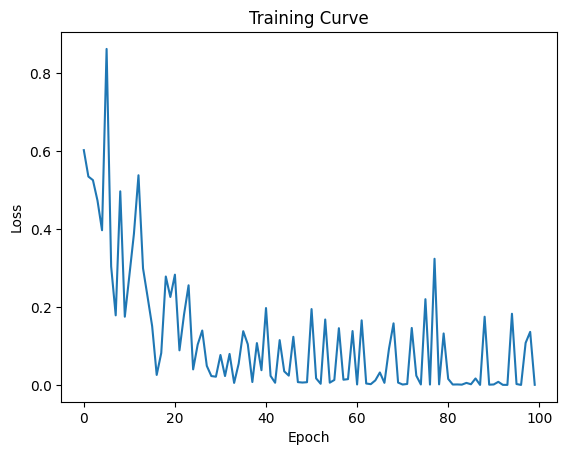

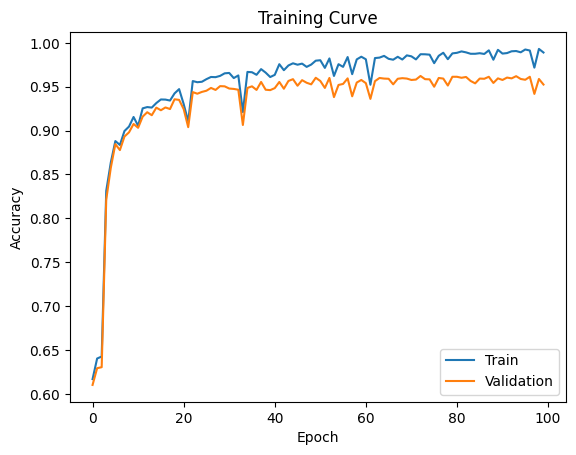

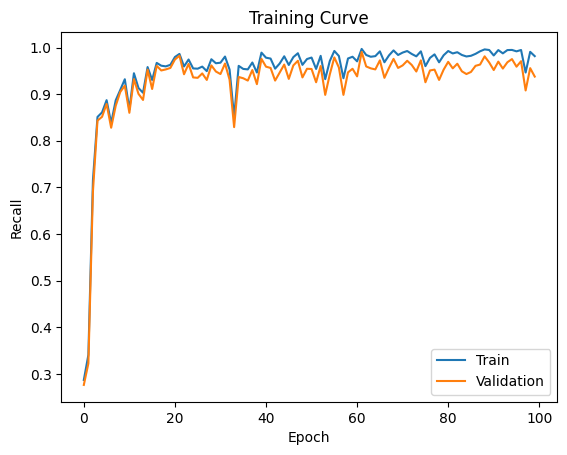

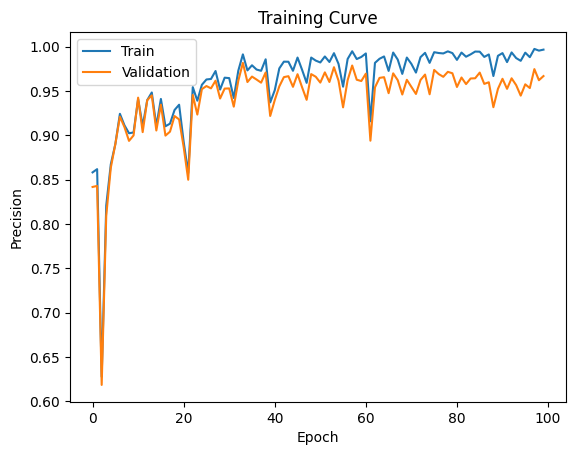

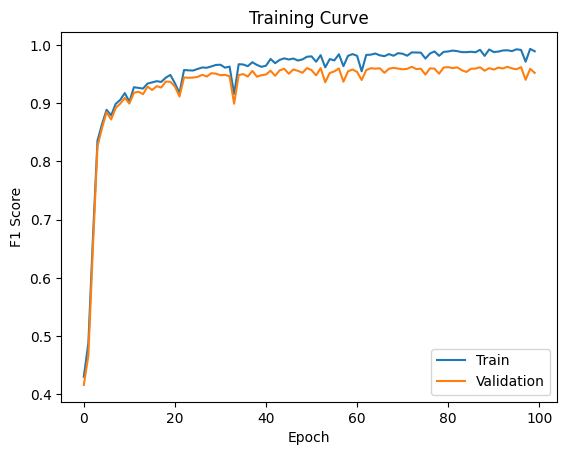

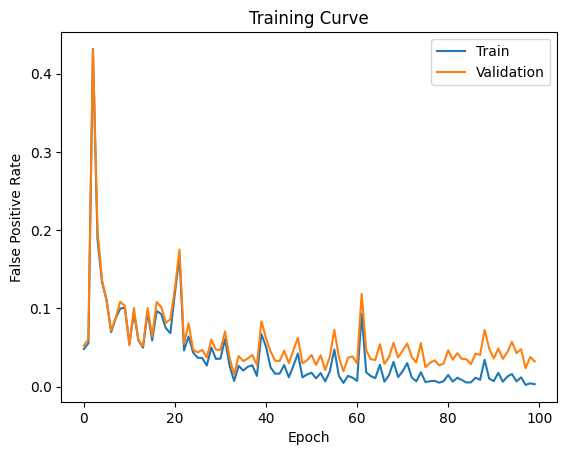

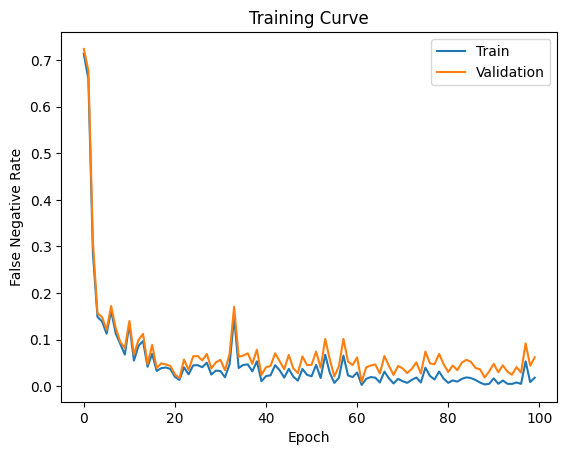

[0.9521646987587042,
 0.9366153846153846,
 0.9651236525047558,
 0.9506558400999375,
 0.032777115613825986,
 0.06338461538461539]

In [ ]:
# we need train, test, valid datasets here

model_2 = ANNClassifier(glove.vectors, lstm_hidden=50, lstm_output=64) # hidden layer does not have to have same size as input
train_loader2 = DualEmailBatcher(train2, batch_size=32, drop_last=True)
valid_loader2 = DualEmailBatcher(valid2, batch_size=32, drop_last=False)
test_loader2 = DualEmailBatcher(test2, batch_size=32, drop_last=False)

train_dual_lstm_network(model_2, train_loader2, valid_loader2, num_epochs=100, learning_rate=1.5e-4)
get_accuracy2(model_2, test_loader2)

In [ ]:
accuracy, recall, precision, f1, fpr, fnr = get_accuracy2(model_2, test_loader2)
print("Test Accuracy:", accuracy)
print("Test Recall:", recall)
print("Test Precision:", precision)
print("Test F1 Score:", f1)
print("Test False Positive Rate:", fpr)
print("Test False Negative Rate:", fnr)

Test Accuracy: 0.9515591886164093
Test Recall: 0.9353846153846154
Test Precision: 0.9650793650793651
Test F1 Score: 0.95
Test False Positive Rate: 0.032777115613825986
Test False Negative Rate: 0.06461538461538462


In [ ]:
unseen = get_email_words(glove, unseen_emails)
unseen_loader = EmailBatcher(unseen, batch_size=64, drop_last=False)
get_accuracy(model_1, unseen_loader)

[0.9719292743168542,
 0.9810943464824577,
 0.9550522031498849,
 0.9678981348637016,
 0.03502240606687349,
 0.018905653517542264]

In [ ]:
# test on unseen data (don't have get_email_words function for dual)